posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values



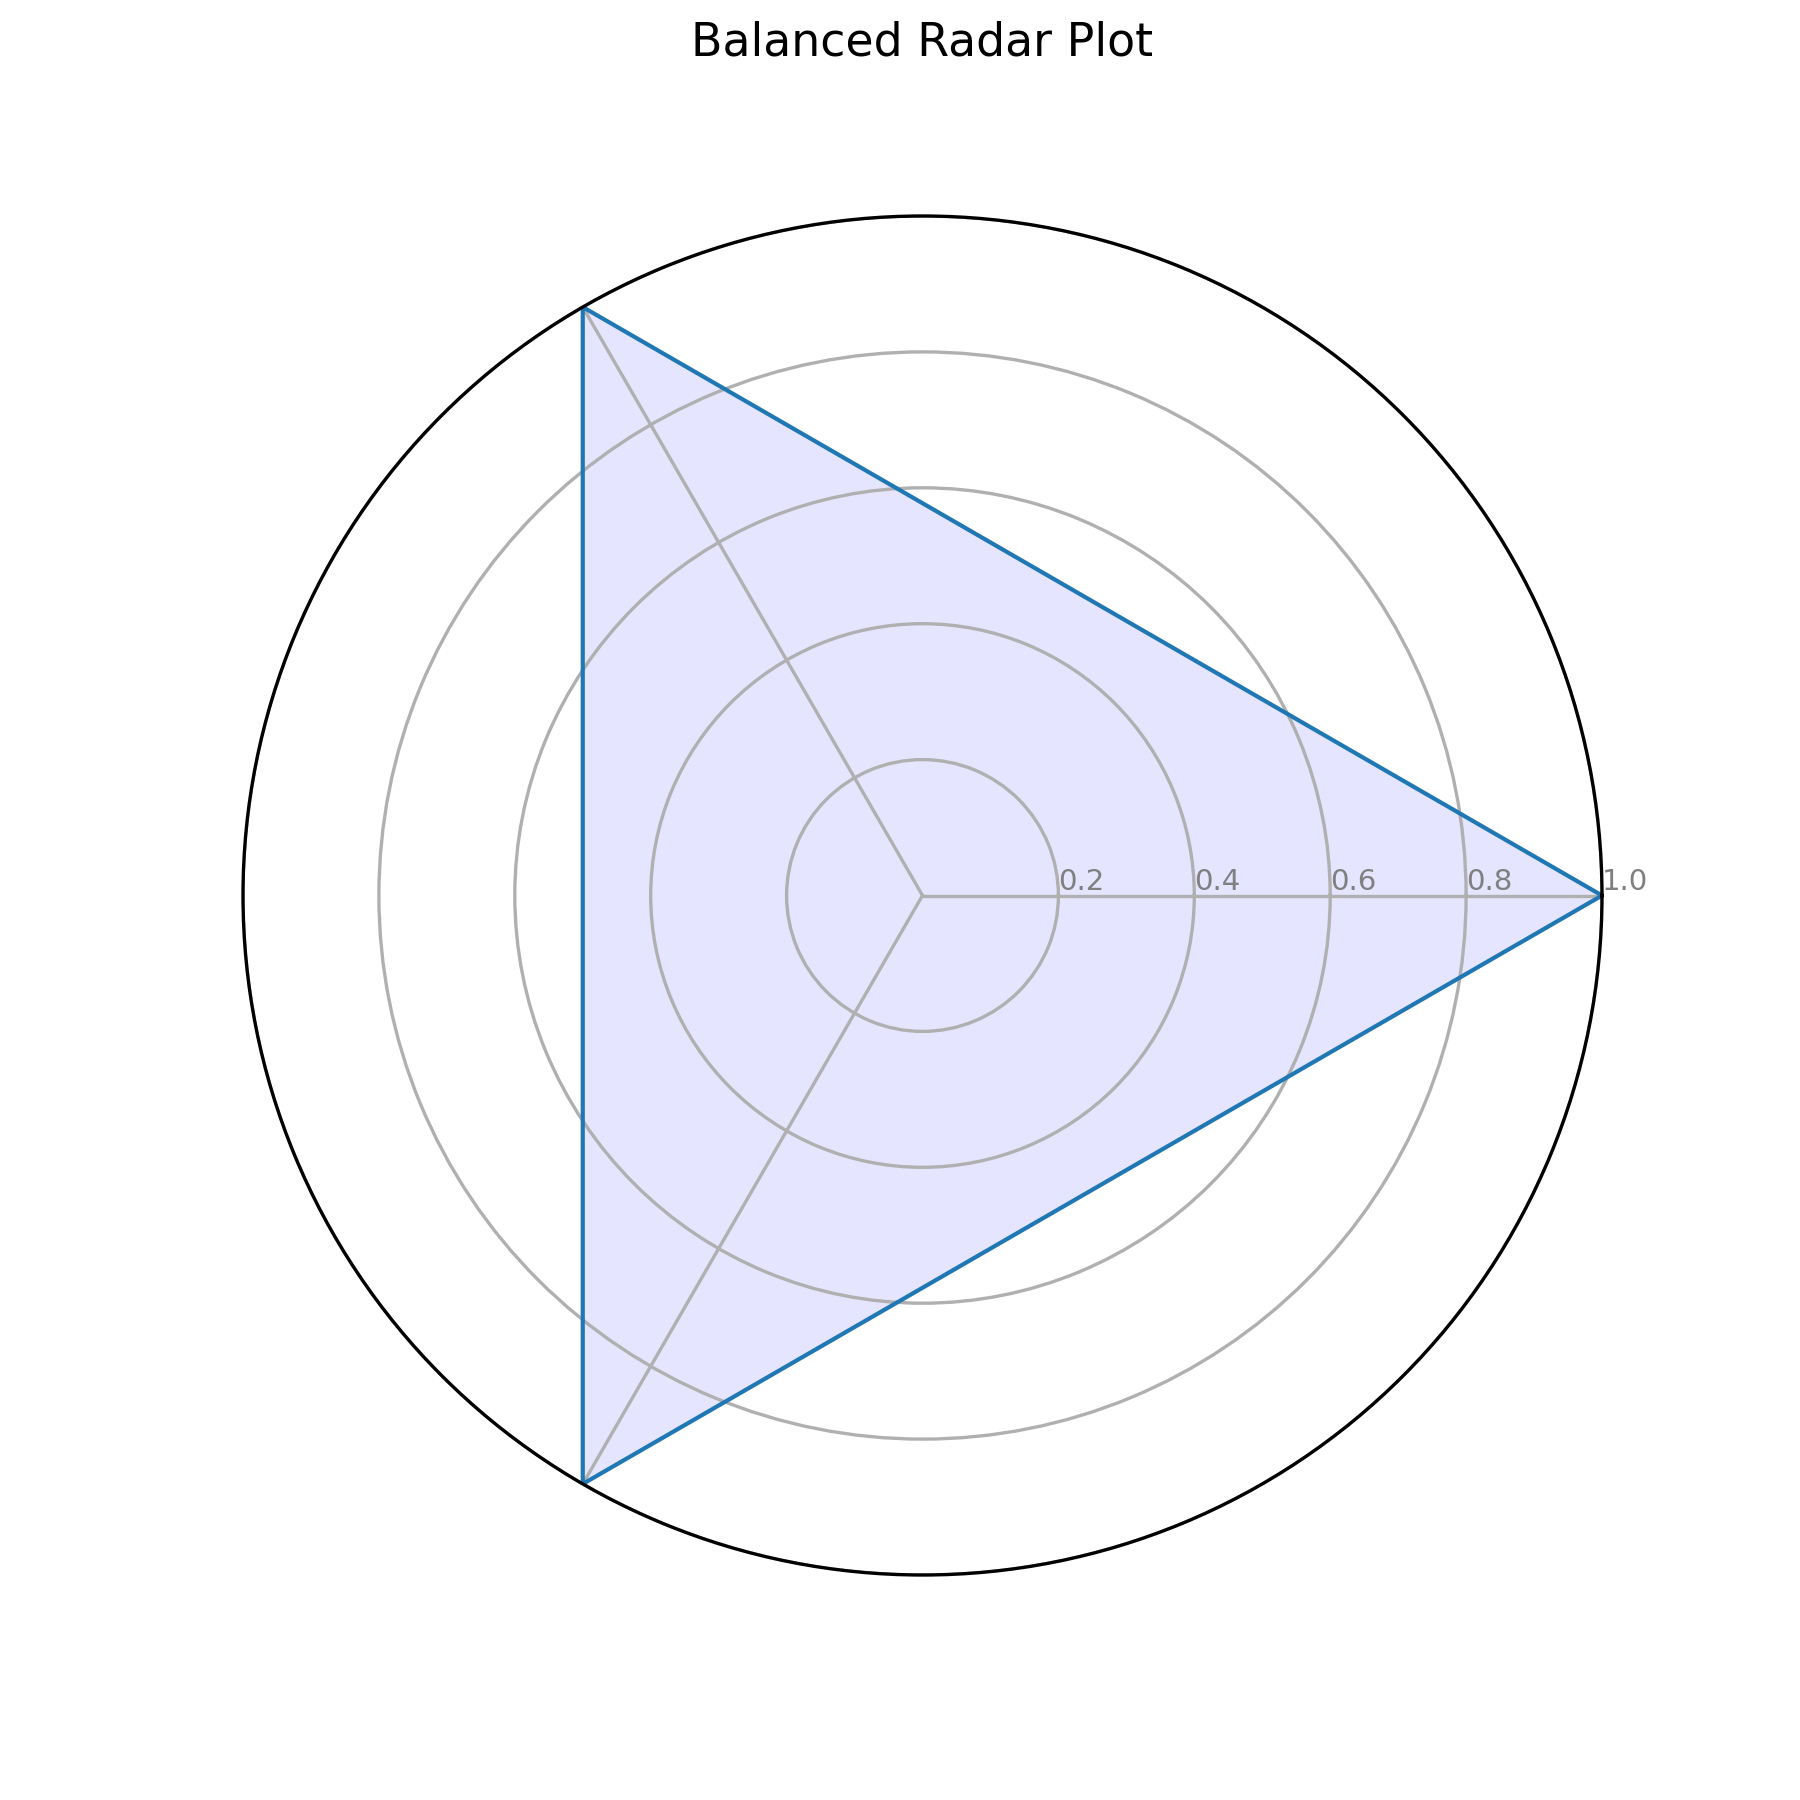
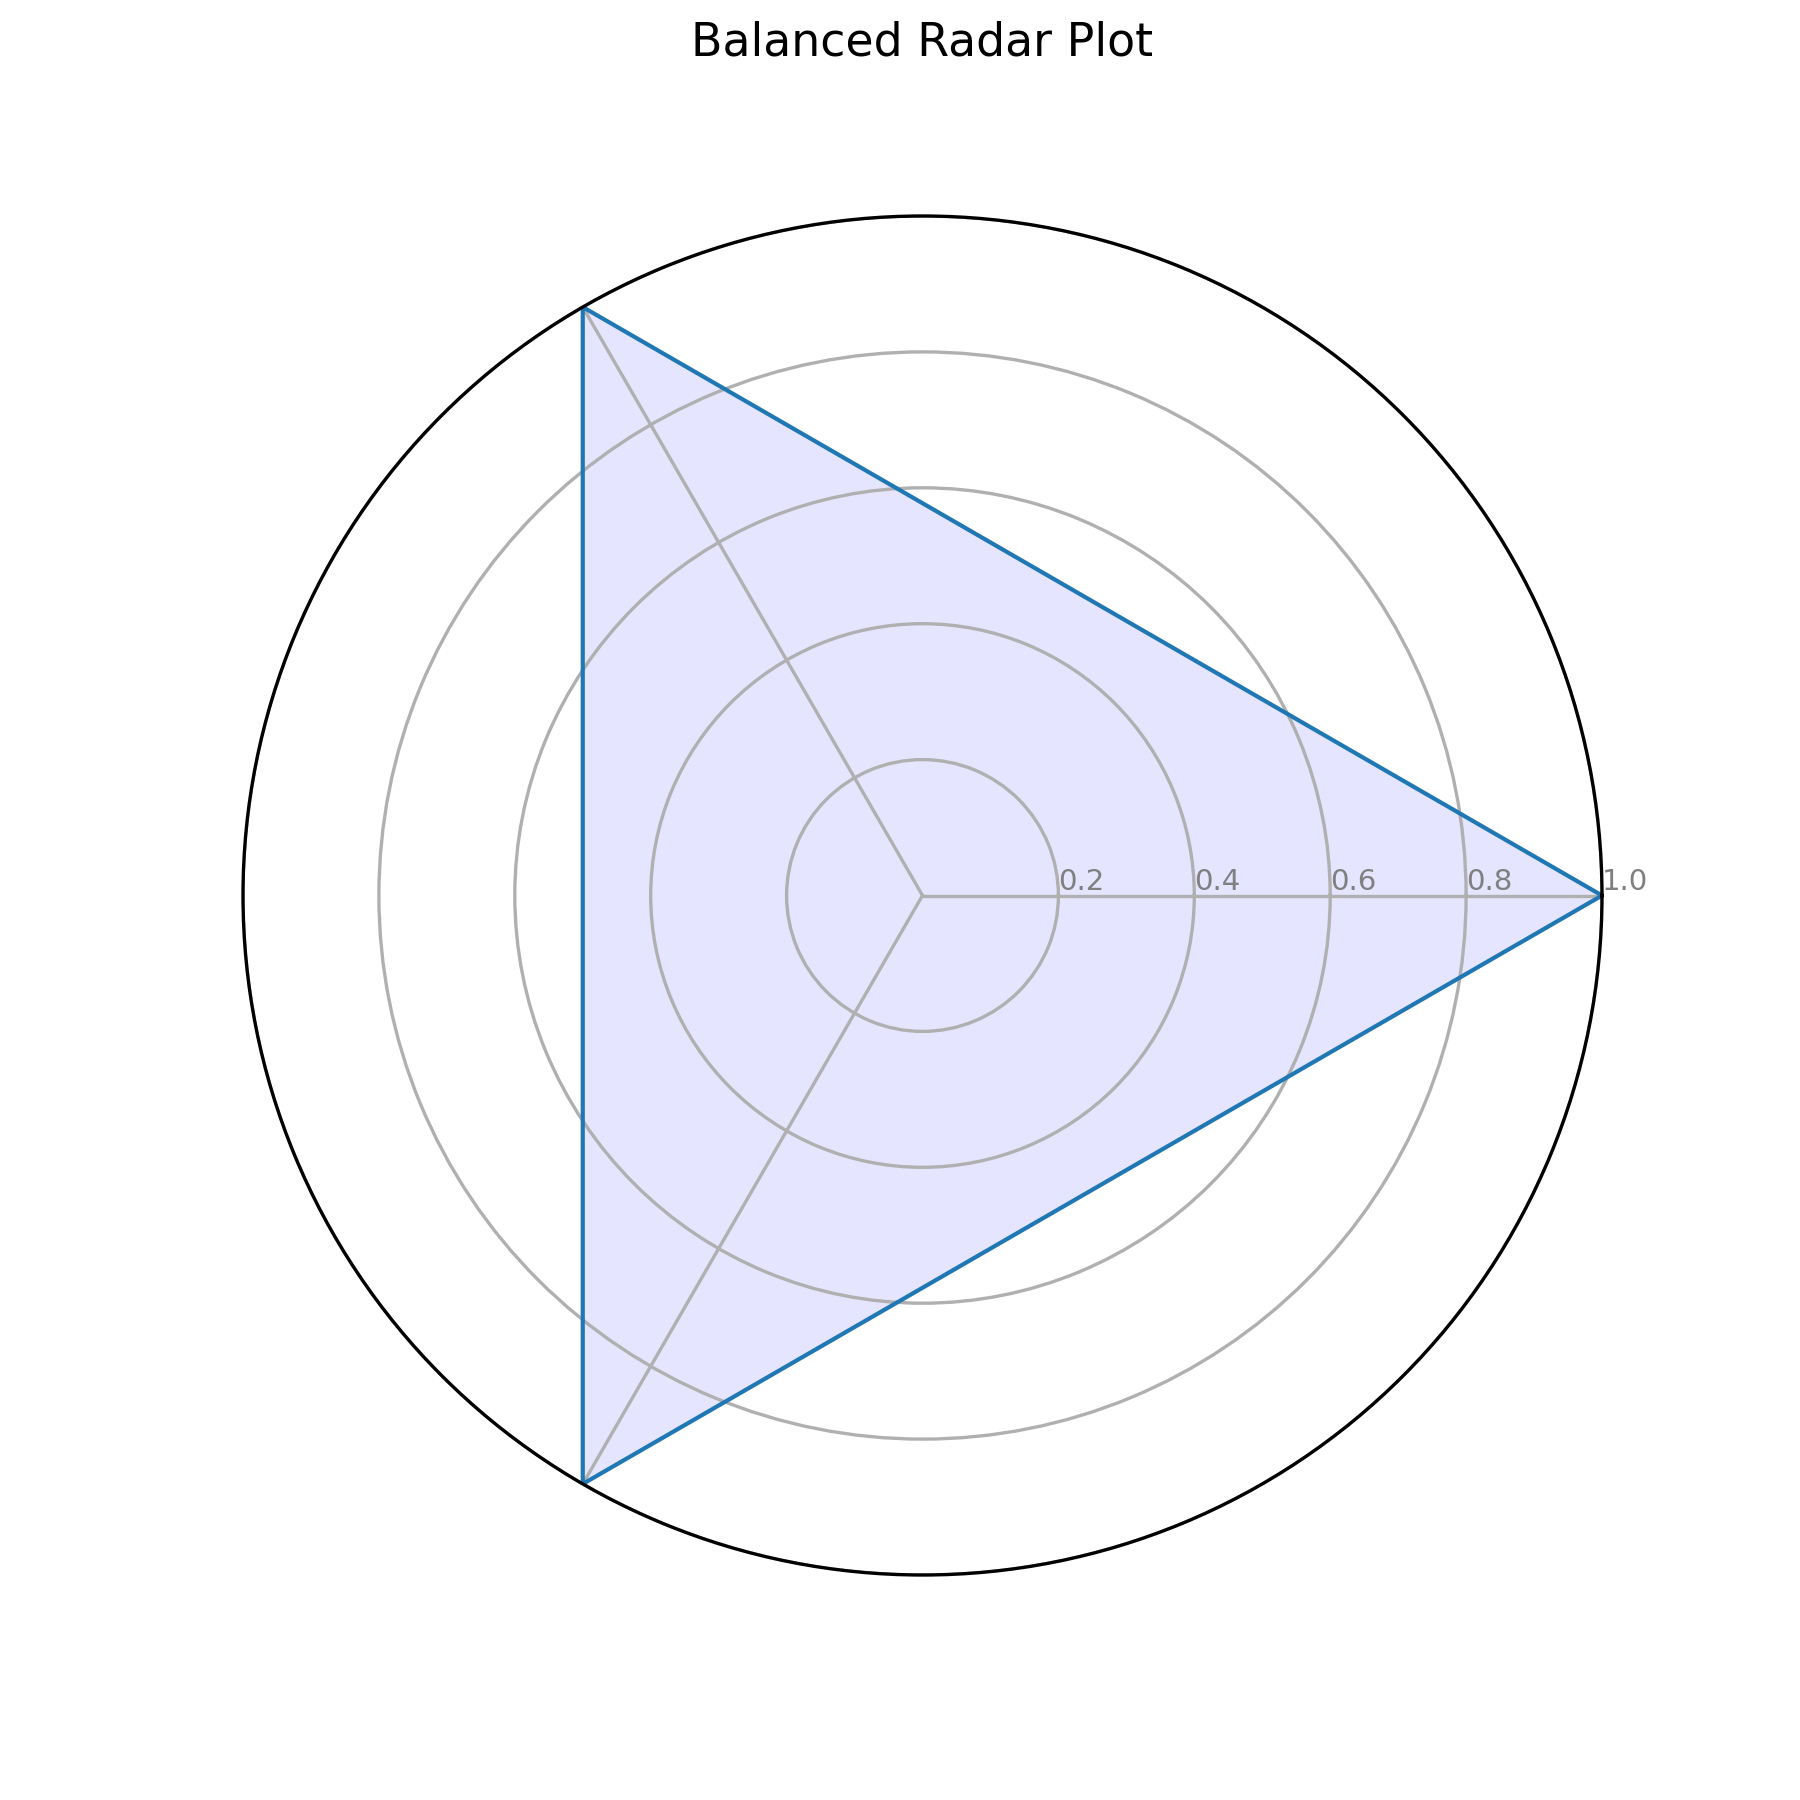

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO
import base64
from IPython.display import display, HTML

def create_radar_plot_image(connectedness, potential, resilience, title="Radar Plot", dpi=300):
    """
    Crea un gráfico de radar con alta resolución y lo devuelve como una imagen codificada en base64.
    """
    categories = ['Connectedness', 'Potential', 'Resilience']
    values = [connectedness, potential, resilience]

    num_vars = len(categories)
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
    angles += angles[:1]

    fig, ax = plt.subplots(1, 1, subplot_kw=dict(polar=True), figsize=(6, 6))

    plt.xticks(angles[:-1], categories, color='grey', size=12, verticalalignment='bottom', y=1.1)

    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=7)
    plt.ylim(0, 1)

    values += values[:1]
    ax.plot(angles, values, linewidth=1, linestyle='solid')
    ax.fill(angles, values, 'b', alpha=0.1)

    plt.title(title, size=11, color='black', y=1.1)

    img = BytesIO()
    # Guardamos la imagen con la resolución especificada (dpi)
    plt.savefig(img, format='png', dpi=dpi)
    img.seek(0)
    plt.close(fig)

    img_base64 = base64.b64encode(img.getvalue()).decode('utf-8')
    return img_base64

def display_radar_plot(connectedness, potential, resilience, title="Radar Plot", filename="radar_plot.png"):
    """
    Muestra el gráfico de radar como una imagen en línea y proporciona un enlace de descarga.
    """
    img_base64 = create_radar_plot_image(connectedness, potential, resilience, title)
    image_url = f"data:image/png;base64,{img_base64}"
    download_link = f'<a href="{image_url}" download="{filename}">Descargar imagen</a>'
    display(HTML(f'<img src="{image_url}" alt="{title}"><br>{download_link}'))

# Ejemplo de uso para un gráfico balanceado (valores aproximadamente iguales):
display_radar_plot(1, 1, 1, title="Balanced Radar Plot")
